# IV.POS.9 Track-B — Multi-guest coverage curves (N=5000, seed 1234)

One figure per **guest program**, with all four variants (V5_control, V6_uniform, V6_cTS,
Hybrid_cTS) overlaid — left panel = local constraint-loc coverage, right = CGC (global) coverage,
cumulative vs mutation index. `g0_baseline` is the reused sha2 campaign (D2.F N=10000 truncated to
the first 5000 mutations). Guests with incomplete data are skipped with a note.

*Caveat:* cross-variant comparison is partly confounded (different selectors/extractors); the rigorous
generalization read is **within-variant across guests** — compare a variant's line on g0 vs the same
variant's line on g1/g2/g3.

In [1]:
import sqlite3, os
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

N = 5000
VARIANTS = ["V5_control", "V6_uniform", "V6_cTS", "Hybrid_cTS"]
COLORS = {"V5_control": "#1f77b4", "V6_uniform": "#2ca02c", "V6_cTS": "#ff7f0e", "Hybrid_cTS": "#d62728"}
PROD = "a4/runs/iv_pos_8/d2f/prod/d2f_prod_b1"
DATA = "a4/runs/iv_pos_9/sweep/data"

def resolve(guest, v):
    if guest == "g0_baseline":
        return f"{PROD}/pos_iv_pos_8_d2f_{v}_seed1234_n10000/run.db"   # truncated to N by cum()
    return f"{DATA}/{guest}_{v}.db"

def cum(db, table):
    if not os.path.exists(db):
        return None
    c = sqlite3.connect(db)
    ids = [int(m) for (m,) in c.execute(f"SELECT first_hit_mutation_id FROM {table}") if m is not None]
    c.close()
    a = np.zeros(N + 1)
    for m in ids:
        if 1 <= m <= N:
            a[m] += 1
    return np.cumsum(a)

def guest_fig(guest):
    x = np.arange(N + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    rows, present = [], 0
    for ax, (table, lbl) in zip(axes, [("coverage", "local constraint-locs"),
                                       ("compressed_global_coverage", "CGC contexts")]):
        for v in VARIANTS:
            cu = cum(resolve(guest, v), table)
            if cu is None:
                continue
            ax.plot(x, cu, color=COLORS[v], lw=2.2, label=f"{v} (final {int(cu[-1])})")
            if table == "coverage":
                present += 1
            rows.append((v, lbl, int(cu[-1])))
        ax.set_title(f"{guest} — {lbl}", fontsize=12)
        ax.set_xlabel("mutation index (0–%d)" % N); ax.set_ylabel(f"distinct {lbl}")
        ax.legend(fontsize=9, loc="lower right", framealpha=0.9); ax.grid(alpha=0.3); ax.margins(x=0)
    fig.suptitle(f"{guest}: coverage trajectories, 4 variants overlaid (N={N}, seed 1234)", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig, rows, present

print("variants present per guest:")
for g in ["g0_baseline", "g1_ecall_control", "g2_mem_stress", "g3_accelerator"]:
    have = [v for v in VARIANTS if os.path.exists(resolve(g, v))]
    print(f"  {g}: {have}")

variants present per guest:
  g0_baseline: ['V5_control', 'V6_uniform', 'V6_cTS', 'Hybrid_cTS']
  g1_ecall_control: ['V5_control', 'V6_uniform', 'V6_cTS', 'Hybrid_cTS']
  g2_mem_stress: ['V5_control', 'V6_uniform', 'V6_cTS', 'Hybrid_cTS']
  g3_accelerator: ['V5_control', 'V6_uniform', 'V6_cTS', 'Hybrid_cTS']


## g0 — sha2 baseline (reused, truncated to 5000)

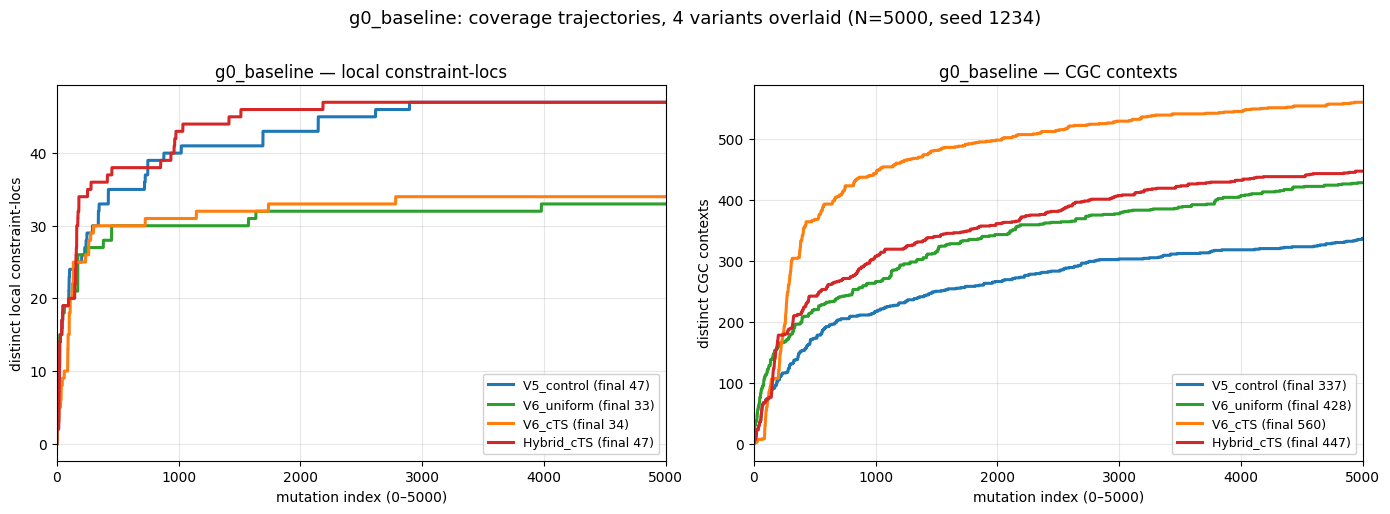

final coverage:
  V5_control     local constraint-locs  47
  V6_uniform     local constraint-locs  33
  V6_cTS         local constraint-locs  34
  Hybrid_cTS     local constraint-locs  47
  V5_control     CGC contexts           337
  V6_uniform     CGC contexts           428
  V6_cTS         CGC contexts           560
  Hybrid_cTS     CGC contexts           447


In [2]:
g = 'g0_baseline'
have = [v for v in VARIANTS if os.path.exists(resolve(g, v))]
if not have:
    print(f"{g}: no completed runs yet — skipped.")
else:
    if len(have) < 4:
        print(f"PARTIAL: only {have} complete for {g} ({4-len(have)} variant(s) still running).")
    fig, rows, _ = guest_fig(g)
    plt.show()
    print("final coverage:")
    for v, lbl, n in rows:
        print(f"  {v:14} {lbl:22} {n}")

## g1 — control/ECALL-heavy guest

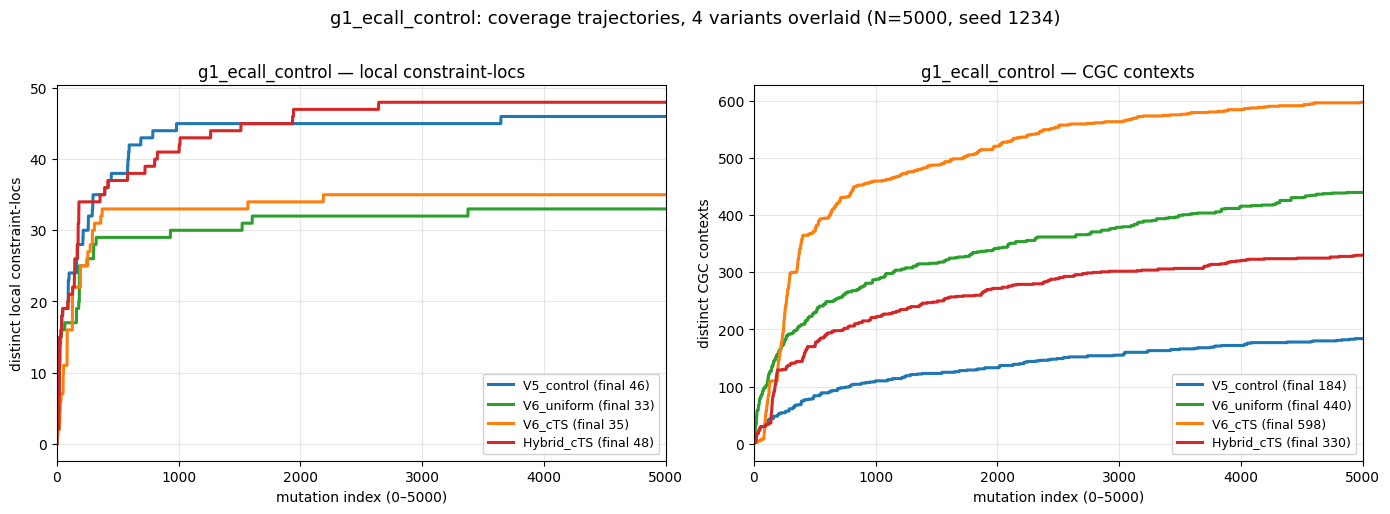

final coverage:
  V5_control     local constraint-locs  46
  V6_uniform     local constraint-locs  33
  V6_cTS         local constraint-locs  35
  Hybrid_cTS     local constraint-locs  48
  V5_control     CGC contexts           184
  V6_uniform     CGC contexts           440
  V6_cTS         CGC contexts           598
  Hybrid_cTS     CGC contexts           330


In [3]:
g = 'g1_ecall_control'
have = [v for v in VARIANTS if os.path.exists(resolve(g, v))]
if not have:
    print(f"{g}: no completed runs yet — skipped.")
else:
    if len(have) < 4:
        print(f"PARTIAL: only {have} complete for {g} ({4-len(have)} variant(s) still running).")
    fig, rows, _ = guest_fig(g)
    plt.show()
    print("final coverage:")
    for v, lbl, n in rows:
        print(f"  {v:14} {lbl:22} {n}")

## g2 — memory-stress guest

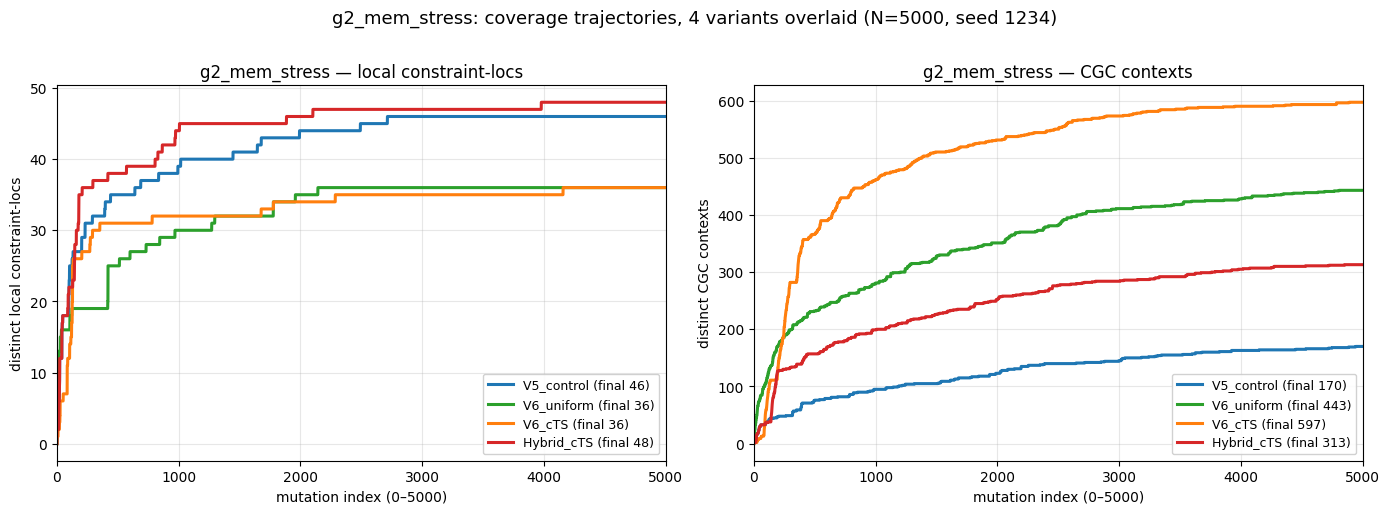

final coverage:
  V5_control     local constraint-locs  46
  V6_uniform     local constraint-locs  36
  V6_cTS         local constraint-locs  36
  Hybrid_cTS     local constraint-locs  48
  V5_control     CGC contexts           170
  V6_uniform     CGC contexts           443
  V6_cTS         CGC contexts           597
  Hybrid_cTS     CGC contexts           313


In [4]:
g = 'g2_mem_stress'
have = [v for v in VARIANTS if os.path.exists(resolve(g, v))]
if not have:
    print(f"{g}: no completed runs yet — skipped.")
else:
    if len(have) < 4:
        print(f"PARTIAL: only {have} complete for {g} ({4-len(have)} variant(s) still running).")
    fig, rows, _ = guest_fig(g)
    plt.show()
    print("final coverage:")
    for v, lbl, n in rows:
        print(f"  {v:14} {lbl:22} {n}")

## g3 — accelerator/SHA guest

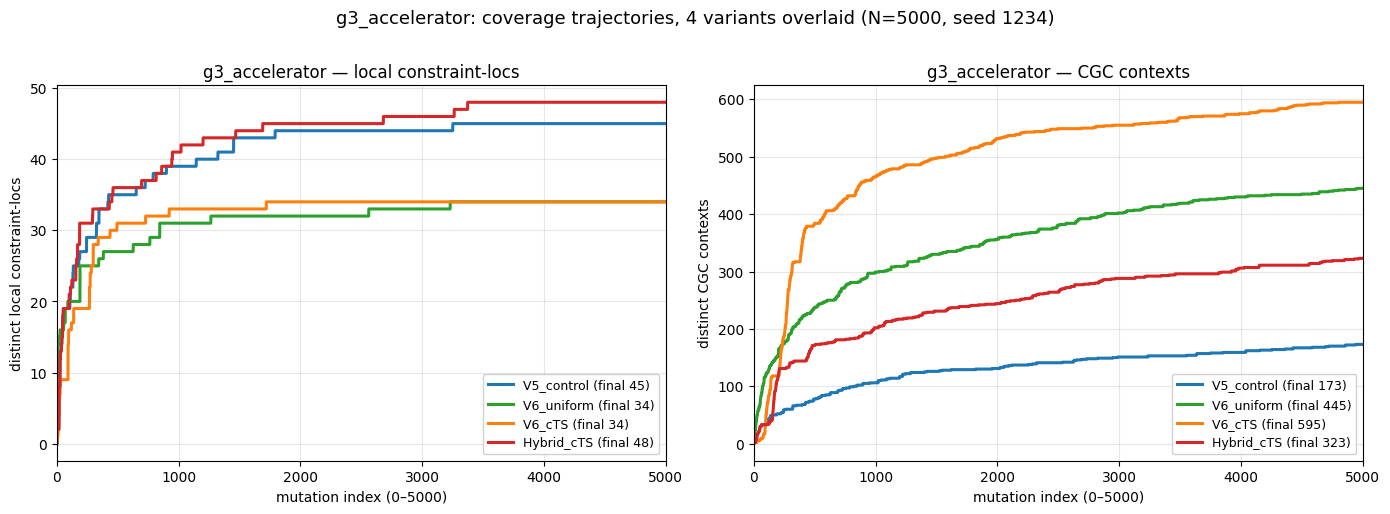

final coverage:
  V5_control     local constraint-locs  45
  V6_uniform     local constraint-locs  34
  V6_cTS         local constraint-locs  34
  Hybrid_cTS     local constraint-locs  48
  V5_control     CGC contexts           173
  V6_uniform     CGC contexts           445
  V6_cTS         CGC contexts           595
  Hybrid_cTS     CGC contexts           323


In [5]:
g = 'g3_accelerator'
have = [v for v in VARIANTS if os.path.exists(resolve(g, v))]
if not have:
    print(f"{g}: no completed runs yet — skipped.")
else:
    if len(have) < 4:
        print(f"PARTIAL: only {have} complete for {g} ({4-len(have)} variant(s) still running).")
    fig, rows, _ = guest_fig(g)
    plt.show()
    print("final coverage:")
    for v, lbl, n in rows:
        print(f"  {v:14} {lbl:22} {n}")